# Pizza vs Not Pizza - CNN + Regularization (Dropout + BatchNorm)

Bu notebookda oldingi `pizza_classification.ipynb` dagi oddiy CNN modelni yaxshilaymiz.

Oldingi modelda **overfitting** bor edi: Train Accuracy ~98% gacha chiqdi, lekin Test Accuracy faqat ~71% bo'lib qoldi.
Bu shuni anglatadiki, model train datasetni "yodlab" oldi, lekin yangi (test) rasmlarni yaxshi tushunmadi.

Buni tuzatish uchun quyidagi o'zgarishlarni kiritamiz:
- **BatchNorm2d** - har bir conv qatlamidan keyin, o'qitishni barqarorlashtiradi va tezlashtiradi
- **Dropout** - har epochda neyronlarning bir qismini tasodifiy o'chirib, modelni "yodlab olish"dan saqlaydi
- Conv qatlamlarda filtrlar sonini ko'paytiramiz (16/32 -> 32/64/128) - model yanada chuqurroq va kuchliroq features o'rganadi

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1. Datasetni yuklash

Rasmlarni 128x128 o'lchamga keltiramiz va tensor ko'rinishiga o'tkazamiz.

In [ ]:
data_dir = "data/pizza_dataset"

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),

    # --- Data Augmentation Starts Here ---
    transforms.RandomHorizontalFlip(p=0.5),         # Flip horizontally 50% of the time
    transforms.RandomRotation(degrees=15),          # Rotate by -15 to +15 degrees
    transforms.ColorJitter(brightness=0.2,          # Randomly change brightness,
                           contrast=0.2,            # contrast,
                           saturation=0.2),         # and saturation
    transforms.RandomAffine(degrees=0,              # Keep rotation 0 (handled above)
                            translate=(0.1, 0.1)),  # Shift horizontally/vertically by 10%
    # --- Data Augmentation Ends Here ---

    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=train_transform)
test_dataset = datasets.ImageFolder(root=f"{data_dir}/test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print("Sinflar:", class_names)
print("Train rasmlar soni:", len(train_dataset))
print("Test rasmlar soni:", len(test_dataset))

Sinflar: ['not_pizza', 'pizza']
Train rasmlar soni: 1600
Test rasmlar soni: 366


## 2. CNN model (BatchNorm + Dropout bilan)

Har bir conv blok endi shu tartibda ishlaydi:
`Conv -> BatchNorm -> ReLU -> MaxPool`

BatchNorm har bir batch uchun activatsiyalarni normallashtiradi (mean=0, std=1 ga yaqinlashtiradi),
shu sababli model tezroq va barqarorroq o'qiydi.

Fully connected qatlamlardan oldin esa **Dropout** qo'shamiz - bu o'qitish vaqtida
neyronlarning bir qismini (masalan 50%) tasodifiy o'chirib turadi, natijada model
faqat ba'zi neyronlarga "qaram" bo'lib qolmaydi va overfitting kamayadi.

In [3]:
class RegularizedCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # 1-blok: 3 -> 32 kanal
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # 2-blok: 32 -> 64 kanal
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # 3-blok: 64 -> 128 kanal (qo'shimcha chuqurlik uchun)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        # 128x128 -> pool -> 64x64 -> pool -> 32x32 -> pool -> 16x16
        self.dropout_conv = nn.Dropout(0.25)   # conv qatlamlardan keyin yengilroq dropout
        self.dropout_fc = nn.Dropout(0.5)      # fc qatlamlarda kuchliroq dropout

        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.dropout_conv(x)

        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.dropout_conv(x)

        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.dropout_conv(x)

        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        return x

model = RegularizedCNN(num_classes=len(class_names)).to(device)
print(model)

RegularizedCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout_conv): Dropout(p=0.25, inplace=False)
  (dropout_fc): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)


## 3. Loss va Optimizer

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 4. Modelni o'qitish (Training)

Diqqat: BatchNorm va Dropout faqat `model.train()` rejimida ishlaydi.
Test/baholash vaqtida `model.eval()` chaqirib, ularni o'chirib qo'yamiz (4-bo'limda).

In [5]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Train Accuracy: {train_acc:.2f}%")

Epoch [1/20], Loss: 3.1939, Train Accuracy: 59.69%
Epoch [2/20], Loss: 0.6381, Train Accuracy: 65.19%
Epoch [3/20], Loss: 0.6169, Train Accuracy: 68.19%
Epoch [4/20], Loss: 0.5991, Train Accuracy: 69.31%
Epoch [5/20], Loss: 0.5774, Train Accuracy: 71.94%
Epoch [6/20], Loss: 0.5764, Train Accuracy: 72.56%
Epoch [7/20], Loss: 0.5609, Train Accuracy: 74.38%
Epoch [8/20], Loss: 0.5496, Train Accuracy: 74.06%
Epoch [9/20], Loss: 0.5504, Train Accuracy: 74.00%
Epoch [10/20], Loss: 0.5171, Train Accuracy: 74.81%
Epoch [11/20], Loss: 0.5103, Train Accuracy: 76.25%
Epoch [12/20], Loss: 0.4875, Train Accuracy: 77.12%
Epoch [13/20], Loss: 0.5173, Train Accuracy: 75.69%
Epoch [14/20], Loss: 0.4785, Train Accuracy: 76.62%
Epoch [15/20], Loss: 0.5133, Train Accuracy: 75.25%
Epoch [16/20], Loss: 0.4896, Train Accuracy: 75.50%
Epoch [17/20], Loss: 0.4892, Train Accuracy: 77.88%
Epoch [18/20], Loss: 0.4783, Train Accuracy: 77.62%
Epoch [19/20], Loss: 0.4982, Train Accuracy: 76.56%
Epoch [20/20], Loss: 

## 5. Test datasetda baholash

`model.eval()` chaqirilganda Dropout o'chadi (barcha neyronlar ishlaydi)
va BatchNorm train paytida hisoblangan statistikalardan (running mean/var) foydalanadi.

In [6]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 75.68%


## 6. Test rasmlarini va bashoratlarini ko'rish

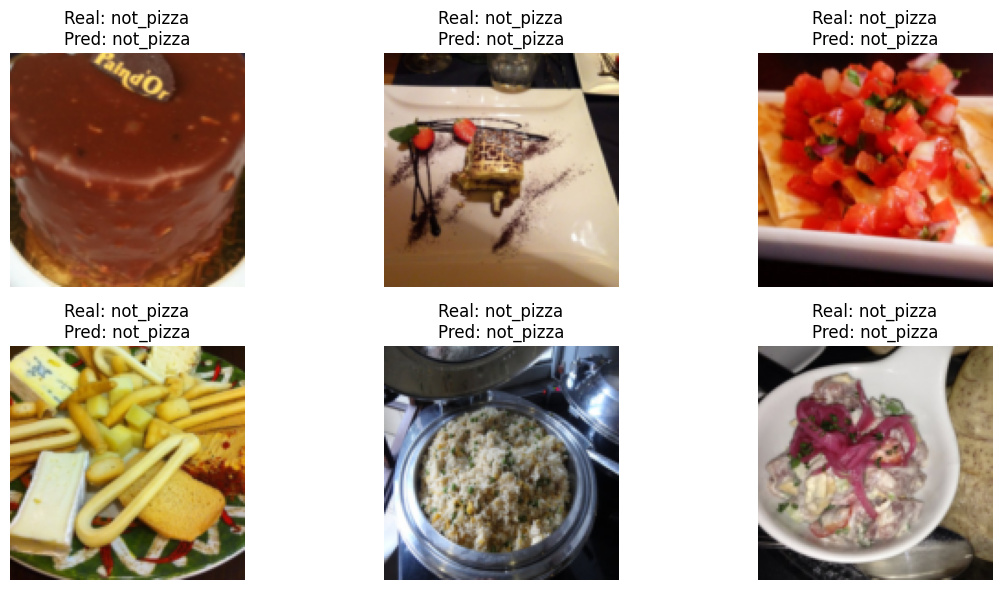

In [7]:
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predictions = torch.max(outputs, 1)

num_show = 6
plt.figure(figsize=(12, 6))
for i in range(num_show):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    real_label = class_names[labels[i]]
    pred_label = class_names[predictions[i]]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Real: {real_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()